In [40]:
# IMPORTACIÓN DE LIBRERÍAS

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [41]:
# Cargamos el archivo CSV con los datos de clientes

df = pd.read_csv('/dataset_segmentacion_clientes.csv')

# Mostramos las primeras filas

df.head()

,purchase_freq_month,avg_basket_usd,time_on_site_min,discount_sensitivity,returns_rate,noise_gauss,noise_uniform
0,11.152508,181.300834,33.564036,1.000000,0.800000,-1.806578,-2.516905
1,12.053451,178.637272,35.432081,0.784974,0.000000,0.645129,2.115460
2,2.203006,450.185298,7.030757,0.898297,0.000000,-0.047406,-0.724173
3,4.233314,89.006342,10.834453,0.000000,0.800000,0.901700,-2.974026
4,1.716799,449.773982,7.254548,0.000000,0.003279,0.386013,2.424522


In [42]:
# Información general del dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700 entries, 0 to 699
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   purchase_freq_month   700 non-null    float64
 1   avg_basket_usd        700 non-null    float64
 2   time_on_site_min      700 non-null    float64
 3   discount_sensitivity  700 non-null    float64
 4   returns_rate          700 non-null    float64
 5   noise_gauss           700 non-null    float64
 6   noise_uniform         700 non-null    float64
dtypes: float64(7)
memory usage: 38.4 KB


In [43]:
# Se eliminan las columnas noise_gauss y noise_uniform
# ya que representan ruido y no aportan información útil
# para la segmentación de clientes.

df = df.drop(
    columns=['noise_gauss', 'noise_uniform']
)

# Mostramos las columnas restantes

df.columns

Index(['purchase_freq_month', 'avg_basket_usd', 'time_on_site_min',
       'discount_sensitivity', 'returns_rate'],
      dtype='object')

In [44]:
# K-Means utiliza distancias euclidianas,
# por eso es importante normalizar los datos

scaler = StandardScaler()

X_scaled = scaler.fit_transform(df)

In [45]:
# Lista para guardar las inercias

inercias = []

# Probamos valores de k entre 2 y 6

for k in range(2,7):

    modelo = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    # Entrenamos el modelo

    modelo.fit(X_scaled)

    # Guardamos la inercia

    inercias.append(modelo.inertia_)

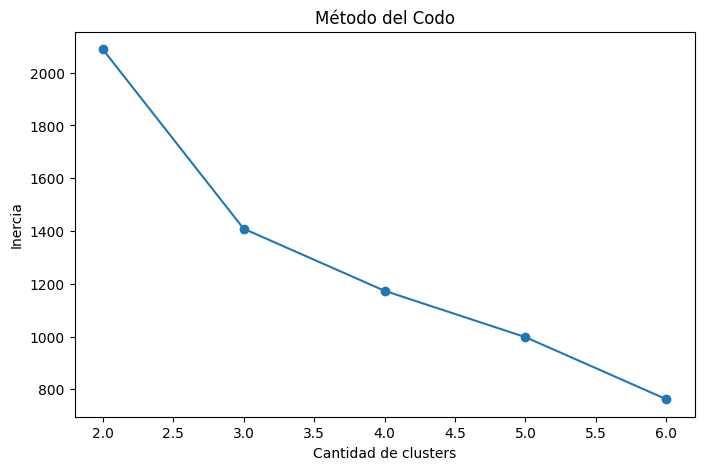

In [46]:
# GRÁFICO DEL MÉTODO DEL CODO

plt.figure(figsize=(8,5))

plt.plot(range(2,7), inercias, marker='o')

plt.xlabel('Cantidad de clusters')
plt.ylabel('Inercia')
plt.title('Método del Codo')

plt.show()

### Interpretación del Método del Codo

En el gráfico se observa que la inercia disminuye a medida que aumenta la cantidad de clusters.  
La caída más marcada se da entre k=2 y k=3, y luego la disminución comienza a ser más gradual.
Por este motivo, se puede considerar que k=3 es un valor razonable para segmentar a los clientes, ya que permite reducir la inercia sin aumentar innecesariamente la cantidad de grupos.
Este análisis se relaciona con la consigna de la clase, donde se solicita comparar valores de k entre 2 y 6 utilizando el método del codo.

In [47]:
# Además del método del codo, se utiliza Silhouette Score
# para evaluar qué tan bien separados están los clusters.

# Un valor más alto indica que los grupos están mejor definidos.

from sklearn.metrics import silhouette_score

silhouette_scores = []

# Probamos valores de k desde 2 hasta 6,
# tal como pide la consigna de la clase.

for k in range(2, 7):

    modelo = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = modelo.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)

    silhouette_scores.append(score)

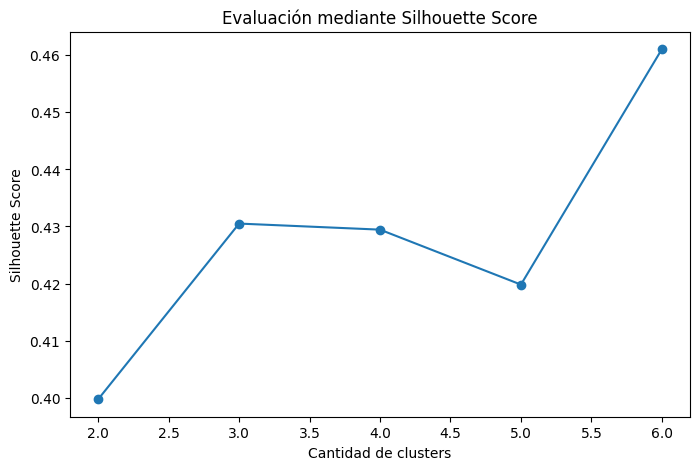

In [48]:
# GRÁFICO DE SILHOUETTE SCORE

plt.figure(figsize=(8,5))

plt.plot(range(2,7), silhouette_scores, marker='o')

plt.xlabel('Cantidad de clusters')
plt.ylabel('Silhouette Score')
plt.title('Evaluación mediante Silhouette Score')

plt.show()

### Interpretación del Silhouette Score

Si bien la consigna principal solicita utilizar el método del codo para justificar el valor de k, también se incorporó el análisis mediante Silhouette Score como técnica complementaria para evaluar la separación entre clusters.

Este método permite analizar qué tan definidos y diferenciados se encuentran los grupos generados por K-Means.

## Entrenamiento final del modelo K-Means

Luego de analizar el Método del Codo y complementar la evaluación mediante Silhouette Score, se selecciona k=3 como cantidad adecuada de clusters.

Esta elección permite segmentar a los clientes en grupos diferenciados según sus hábitos de compra, sensibilidad a descuentos, permanencia en el sitio y comportamiento general.

In [49]:
# Se selecciona k=3 como cantidad final
# de clusters para segmentar a los clientes.

kmeans = KMeans(
    n_clusters=3,
    init='k-means++',
    random_state=42,
    n_init=10,
    max_iter=300
)

# Entrenamos el modelo utilizando
# los datos previamente escalados.

kmeans.fit(X_scaled)

KMeans(n_clusters=3, n_init=10, random_state=42)

In [50]:
# Se crea una nueva columna llamada
# "cluster" con el grupo asignado
# a cada cliente.

df['cluster'] = kmeans.labels_

# Mostramos las primeras filas
# del dataset actualizado.

df.head()

,purchase_freq_month,avg_basket_usd,time_on_site_min,discount_sensitivity,returns_rate,cluster
0,11.152508,181.300834,33.564036,1.000000,0.800000,0
1,12.053451,178.637272,35.432081,0.784974,0.000000,0
2,2.203006,450.185298,7.030757,0.898297,0.000000,1
3,4.233314,89.006342,10.834453,0.000000,0.800000,2
4,1.716799,449.773982,7.254548,0.000000,0.003279,1


## Análisis de centroides

Los centroides representan el comportamiento promedio de cada grupo de clientes encontrado por el algoritmo K-Means.

Analizando los valores promedio de cada variable, es posible identificar perfiles diferenciados de clientes según:

- frecuencia de compra,
- ticket promedio,
- sensibilidad a descuentos,
- tiempo de permanencia en el sitio,
- y tasa de devoluciones.

In [51]:
# CÁLCULO DE CENTROIDES

# Convertimos los centroides nuevamente
# a la escala original de los datos.

centroides = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=df.columns[:-1]
)

# Mostramos los centroides

centroides

,purchase_freq_month,avg_basket_usd,time_on_site_min,discount_sensitivity,returns_rate
0,11.961153,179.999315,35.022131,0.541539,0.332461
1,1.846908,450.123746,5.973739,0.358088,0.375371
2,4.091883,89.957567,10.003793,0.379465,0.298761


In [52]:
# Calculamos el promedio de cada variable
# según el cluster asignado.

df.groupby('cluster').mean()

,purchase_freq_month,avg_basket_usd,time_on_site_min,discount_sensitivity,returns_rate
cluster,,,,,
0,11.961153,179.999315,35.022131,0.541539,0.332461
1,1.846908,450.123746,5.973739,0.358088,0.375371
2,4.091883,89.957567,10.003793,0.379465,0.298761


## Visualización de clusters y centroides

A continuación se representa gráficamente la segmentación obtenida mediante K-Means.

Cada color representa un cluster distinto de clientes, mientras que los centroides indican el centro promedio de cada grupo.

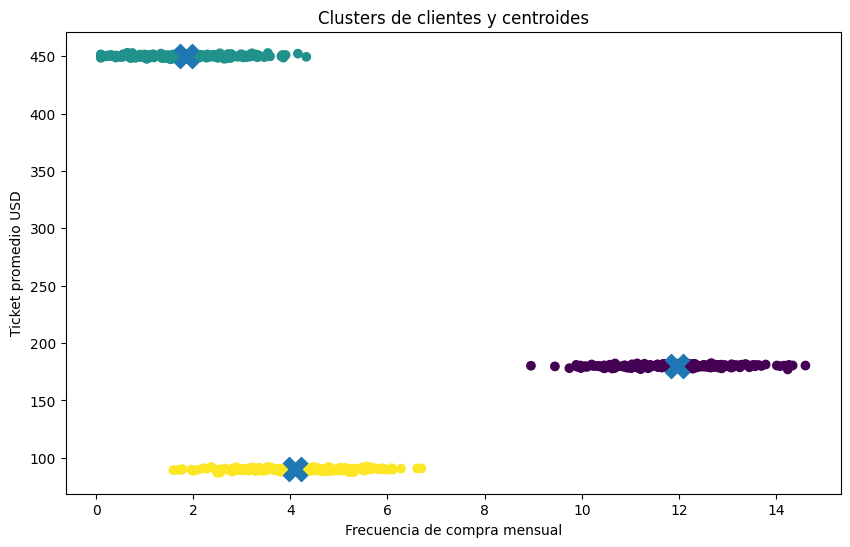

In [53]:
# VISUALIZACIÓN DE CLUSTERS Y CENTROIDES

# Graficamos frecuencia de compra
# y ticket promedio.

plt.figure(figsize=(10,6))

# Clientes

plt.scatter(
    df['purchase_freq_month'],
    df['avg_basket_usd'],
    c=df['cluster']
)

# Centroides

plt.scatter(
    centroides['purchase_freq_month'],
    centroides['avg_basket_usd'],
    s=300,
    marker='X'
)

plt.xlabel('Frecuencia de compra mensual')
plt.ylabel('Ticket promedio USD')

plt.title('Clusters de clientes y centroides')

plt.show()

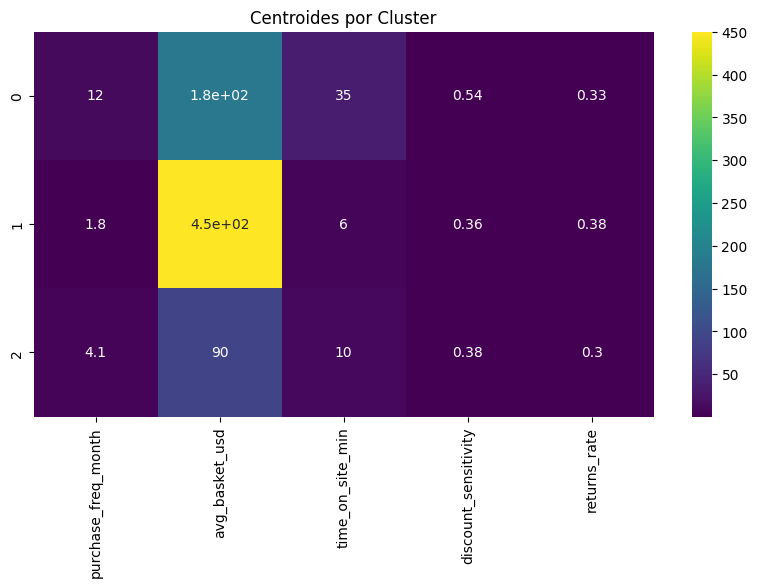

In [54]:
# HEATMAP DE CENTROIDES

# Visualizamos los centroides mediante
# un mapa de calor para comparar
# los valores de cada cluster.

plt.figure(figsize=(10,5))

sns.heatmap(
    centroides,
    annot=True,
    cmap='viridis'
)

plt.title('Centroides por Cluster')

plt.show()

## Reducción de dimensionalidad con PCA

Se utiliza PCA (Principal Component Analysis) para representar los clusters en dos dimensiones y visualizar de forma más clara la separación entre grupos.

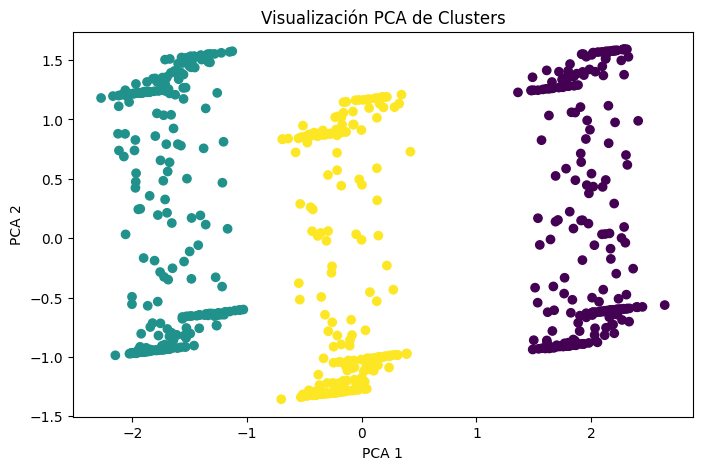

In [55]:
# VISUALIZACIÓN MEDIANTE PCA
from sklearn.decomposition import PCA

# Reducimos las variables a 2 dimensiones

pca = PCA(n_components=2)

clientes_pca = pca.fit_transform(X_scaled)

# Graficamos los clusters

plt.figure(figsize=(8,5))

plt.scatter(
    clientes_pca[:,0],
    clientes_pca[:,1],
    c=df['cluster']
)

plt.xlabel('PCA 1')
plt.ylabel('PCA 2')

plt.title('Visualización PCA de Clusters')

plt.show()

## Interpretación de clusters

A partir del análisis de los centroides y de la visualización de los clusters, se identificaron tres perfiles principales de clientes.

### Cluster 0: clientes frecuentes y sensibles a promociones

Este grupo presenta una alta frecuencia de compra mensual, un ticket promedio medio y mayor tiempo de permanencia en el sitio.  
También muestra una sensibilidad a descuentos relativamente alta.
Este perfil puede asociarse a clientes activos, que compran seguido y pueden responder bien a promociones, descuentos o estrategias de fidelización.

### Cluster 1: clientes premium o de compras esporádicas grandes

Este grupo presenta una baja frecuencia de compra, pero un ticket promedio muy alto.  
Esto indica que son clientes que compran pocas veces, pero realizan compras de mayor valor económico.
Este perfil puede ser útil para estrategias de upselling, productos premium o beneficios especiales.

### Cluster 2: clientes ocasionales de bajo gasto

Este grupo presenta una frecuencia de compra intermedia-baja y un ticket promedio bajo.  
También tiene menor tiempo de permanencia en el sitio en comparación con el Cluster 0.
Este perfil puede representar clientes más ocasionales, con menor nivel de gasto, a los que se podría intentar incentivar mediante recomendaciones personalizadas o campañas específicas.

## Conclusión Personal

En este trabajo se aplicó el algoritmo K-Means para realizar una segmentación de clientes a partir de variables relacionadas con frecuencia de compra, ticket promedio, tiempo en el sitio, sensibilidad a descuentos y tasa de devoluciones.
Primero se eliminaron variables de ruido y se escalaron los datos, ya que K-Means trabaja con distancias y puede verse afectado por variables con escalas diferentes.
Luego se compararon distintos valores de k entre 2 y 6 mediante el Método del Codo. A partir de este análisis se seleccionó k=3 como un valor razonable, ya que permite obtener una segmentación clara sin generar una cantidad excesiva de grupos.
El análisis de centroides permitió interpretar los perfiles encontrados: clientes frecuentes sensibles a promociones, clientes premium de compras esporádicas grandes y clientes ocasionales de menor gasto.
De esta manera, el aprendizaje no supervisado permitió descubrir segmentos latentes de clientes sin utilizar etiquetas previas, cumpliendo con el objetivo de la actividad.